In [115]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [116]:
df = pd.read_csv(r"C:\Users\Lenovo\Downloads\Housing.csv")

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [117]:
df.shape

(545, 13)

In [118]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'mainroad',
       'guestroom', 'basement', 'hotwaterheating', 'airconditioning',
       'parking', 'prefarea', 'furnishingstatus'],
      dtype='str')

In [119]:
y = df["price"]

In [120]:
X = df.drop("price", axis=1)

In [121]:
df.isnull().sum()

price               0
area                0
bedrooms            0
bathrooms           0
stories             0
mainroad            0
guestroom           0
basement            0
hotwaterheating     0
airconditioning     0
parking             0
prefarea            0
furnishingstatus    0
dtype: int64

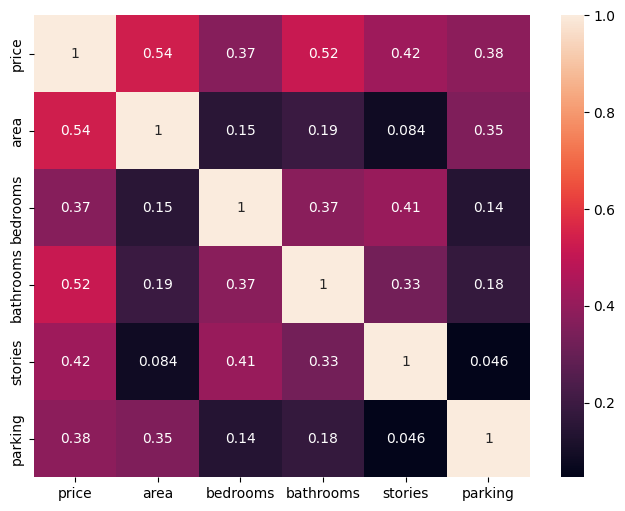

In [122]:
numeric_df = df.select_dtypes(include=["int64", "float64"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True)
plt.show()

In [123]:
df = pd.get_dummies(df, drop_first=True)

df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [124]:
df.columns

Index(['price', 'area', 'bedrooms', 'bathrooms', 'stories', 'parking',
       'mainroad_yes', 'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')

In [125]:
X = df.drop("price", axis=1)

y = df["price"]

In [126]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [127]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [128]:
y_pred = model.predict(X_test)

In [129]:
from sklearn.metrics import mean_absolute_error, r2_score

print("MAE:", mean_absolute_error(y_test, y_pred))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 970043.4039201637
R2 Score: 0.6529242642153184


In [130]:
df.head()

,price,area,bedrooms,bathrooms,stories,parking,mainroad_yes,guestroom_yes,basement_yes,hotwaterheating_yes,airconditioning_yes,prefarea_yes,furnishingstatus_semi-furnished,furnishingstatus_unfurnished
0,13300000,7420,4,2,3,2,True,False,False,False,True,True,False,False
1,12250000,8960,4,4,4,3,True,False,False,False,True,False,False,False
2,12250000,9960,3,2,2,2,True,False,True,False,False,True,True,False
3,12215000,7500,4,2,2,3,True,False,True,False,True,True,False,False
4,11410000,7420,4,1,2,2,True,True,True,False,True,False,False,False


In [131]:
coefficients = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.coef_
})

coefficients.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
2,bathrooms,1.094445e+06
9,airconditioning_yes,7.914267e+05
8,hotwaterheating_yes,6.846499e+05
10,prefarea_yes,6.298906e+05
3,stories,4.074766e+05
7,basement_yes,3.902512e+05
5,mainroad_yes,3.679199e+05
6,guestroom_yes,2.316100e+05
4,parking,2.248419e+05
1,bedrooms,7.677870e+04


In [132]:
X.columns

Index(['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'mainroad_yes',
       'guestroom_yes', 'basement_yes', 'hotwaterheating_yes',
       'airconditioning_yes', 'prefarea_yes',
       'furnishingstatus_semi-furnished', 'furnishingstatus_unfurnished'],
      dtype='str')

In [133]:
area = float(input("Enter Area: "))
bedrooms = int(input("Enter Bedrooms: "))
bathrooms = int(input("Enter Bathrooms: "))
stories = int(input("Enter Stories: "))
parking = int(input("Enter Parking Spaces: "))

mainroad_yes = int(input("Main Road? (1=Yes, 0=No): "))
guestroom_yes = int(input("Guest Room? (1=Yes, 0=No): "))
basement_yes = int(input("Basement? (1=Yes, 0=No): "))
hotwaterheating_yes = int(input("Hot Water Heating? (1=Yes, 0=No): "))
airconditioning_yes = int(input("Air Conditioning? (1=Yes, 0=No): "))
prefarea_yes = int(input("Preferred Area? (1=Yes, 0=No): "))

furnishingstatus_semi_furnished = int(input("Semi-Furnished? (1=Yes, 0=No): "))
furnishingstatus_unfurnished = int(input("Unfurnished? (1=Yes, 0=No): "))

In [134]:
user_data = pd.DataFrame([[
    area,
    bedrooms,
    bathrooms,
    stories,
    parking,
    mainroad_yes,
    guestroom_yes,
    basement_yes,
    hotwaterheating_yes,
    airconditioning_yes,
    prefarea_yes,
    furnishingstatus_semi_furnished,
    furnishingstatus_unfurnished
]], columns=X.columns)

In [135]:
predicted_price = model.predict(user_data)

print("Predicted House Price: ₹", round(predicted_price[0], 2))

Predicted House Price: ₹ 5186428.48


In [136]:
import joblib

joblib.dump(model, "house_price_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


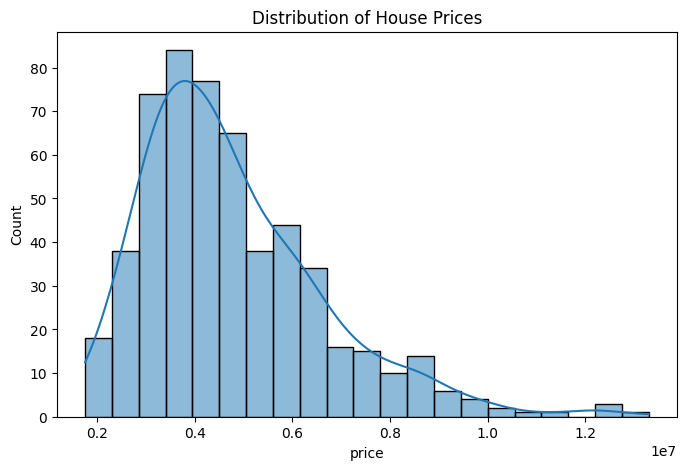

In [137]:
plt.figure(figsize=(8,5))
sns.histplot(df["price"], kde=True)
plt.title("Distribution of House Prices")
plt.show()

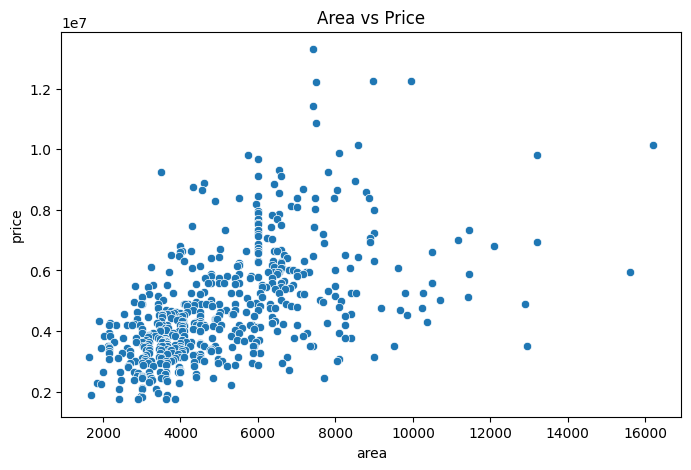

In [138]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="area", y="price", data=df)
plt.title("Area vs Price")
plt.show()

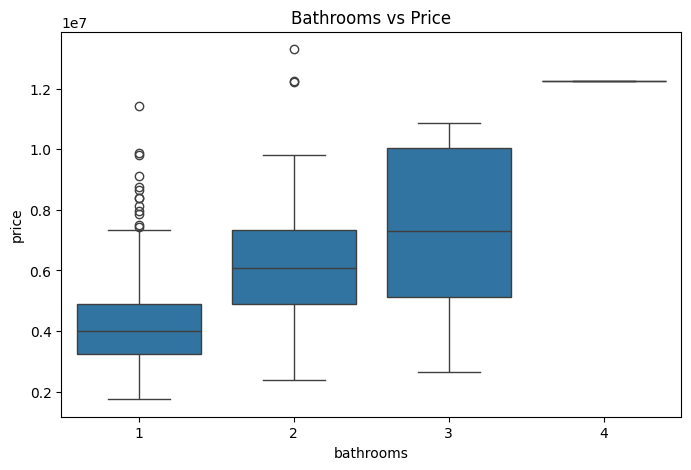

In [139]:
plt.figure(figsize=(8,5))
sns.boxplot(x="bathrooms", y="price", data=df)
plt.title("Bathrooms vs Price")
plt.show()

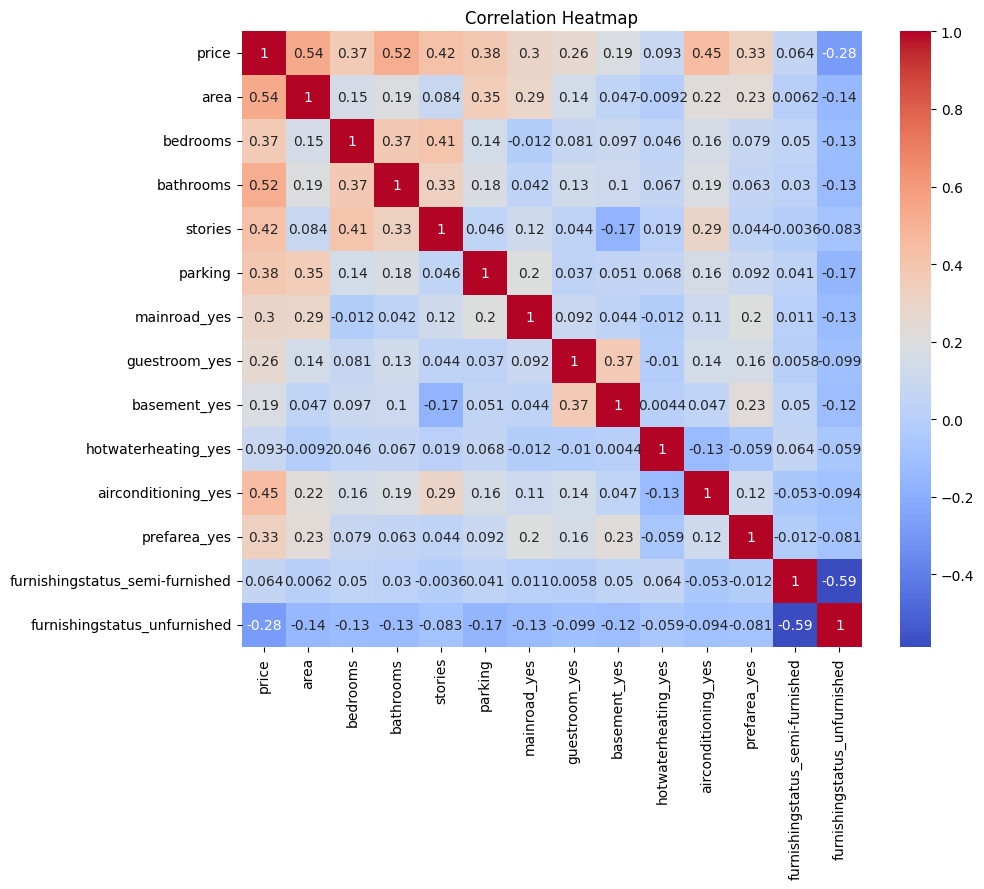

In [140]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

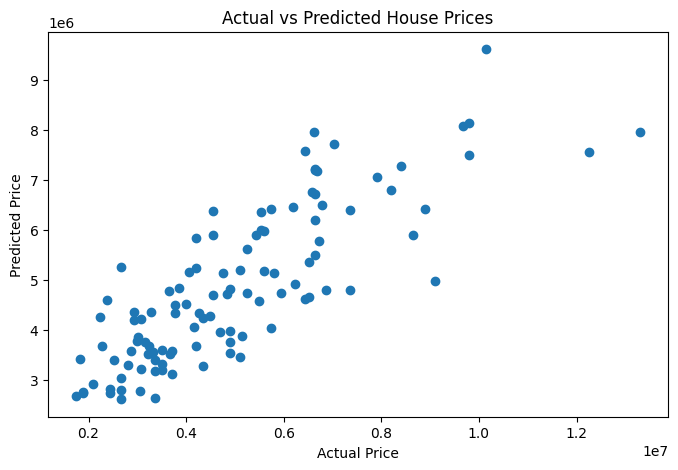

In [141]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

In [ ]:
import joblib

joblib.dump(model, "house_price_model.pkl")
print("Model saved successfully!")